## Importing the libraries

In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

## Importing the dataset

In [4]:
df = pd.read_csv("marketing_and_sales_clean.csv")
df.head()

,TV,Radio,Social Media,Influencer,Sales
0,16.0,6.566231,2.907983,4,54.732757
1,13.0,9.237765,2.409567,4,46.677897
2,41.0,15.886446,2.913410,4,150.177829
3,83.0,30.020028,6.922304,4,298.246340
4,15.0,8.437408,1.405998,2,56.594181


In [5]:
df.describe()

,TV,Radio,Social Media,Influencer,Sales
count,4546.000000,4546.000000,4546.000000,4546.00000,4546.000000
mean,54.062912,18.157533,3.323473,2.50198,192.413332
std,26.104942,9.663260,2.211254,1.12071,93.019873
min,10.000000,0.000684,0.000031,1.00000,31.199409
25%,32.000000,10.555355,1.530822,2.00000,112.434612
50%,53.000000,17.859513,3.055565,2.00000,188.963678
75%,77.000000,25.640603,4.804919,4.00000,272.324236
max,100.000000,48.871161,13.981662,4.00000,364.079751


## Correlation

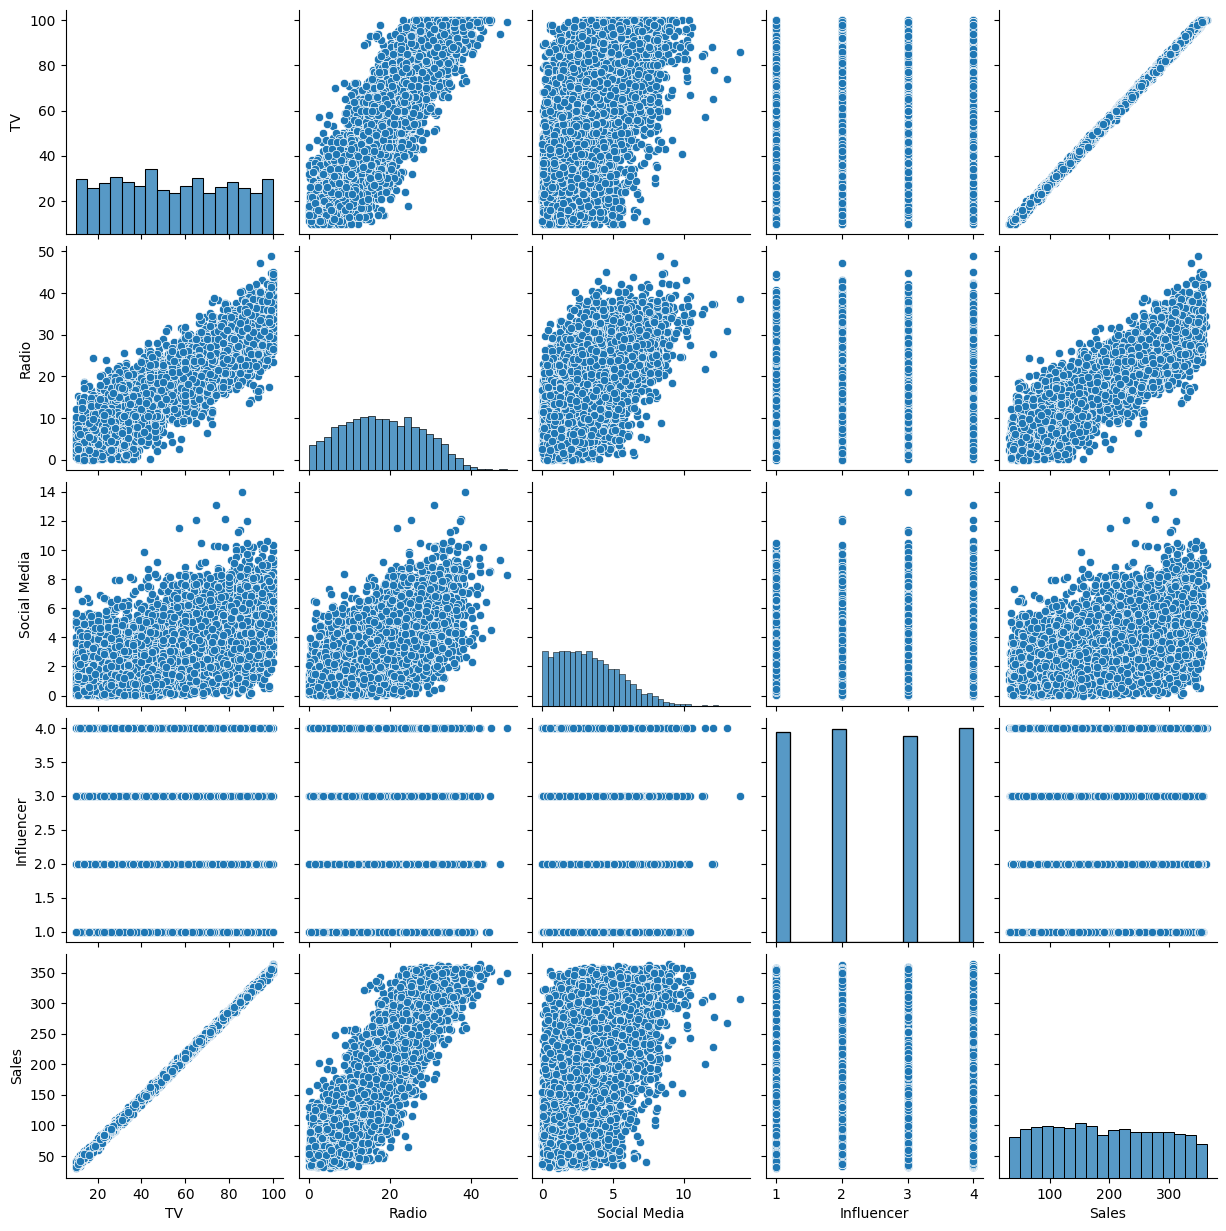

In [ ]:
# Relations entre variables (numériques)
sns.pairplot(df)
plt.show()

## Interprétation
Ces graphiques nous indiquent que le budget investis dans chaque canal de communication n'impacte pas les ventes à la même échelle. L'augmentation d'un budget TV et Radio résulte nécessairement en une hausse des ventes là ou l'augmentation du budget Social media implique des résultats plus nuancés.

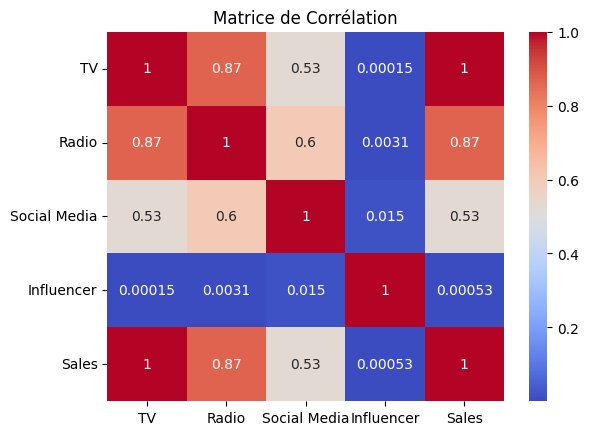

In [8]:
# Calcul de la corrélation
corr_matrix = df.corr()

# Affichage graphique
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Matrice de Corrélation")
plt.show()

## Interprétation 
Cette matrice de corrélation nous permet de mettre en évidence une potentielle multicolinéarité entre le budget TV et Radio. Cela peut constituer un problème dans l'apprentissage de nos modeles car il est difficile d'estimer justement l'influence réelle de chacun de ces 2 canaux puisqu'ils évoluent ensemble constamment.\
On peut considérer des modèles de regressions conçus pour gérer la multicolinéarité (Ridge ? Lasso ?) ou complètement supprimer une des deux colonnes si cette contrainte est bloquante.

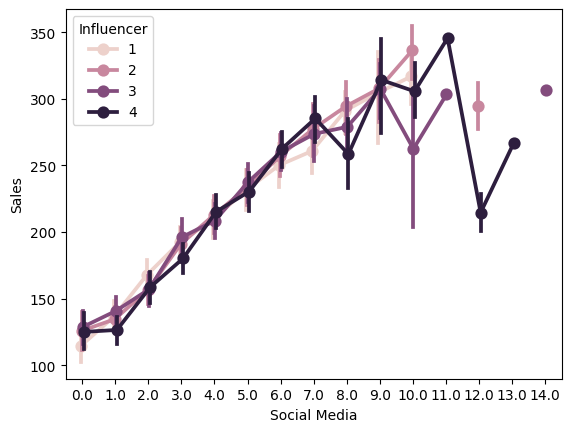

In [7]:

# Relations entre variables (social media)
df_media_rounded = df
# On arrondit le budget au million pour faciliter la lecture du pointplot
df_media_rounded["Social Media"] = df_media_rounded["Social Media"].round()
sns.pointplot(df_media_rounded, x="Social Media", y="Sales", hue="Influencer", dodge=True)
plt.show()

## Interprétation
Ce graphique sépare les différentes types d'influenceur sur lesquelles nous investissons le budget média. Il nous permet d'observer une hausse globale du budget jusqu'à un certain seuil. On observe que l'investissement dans les micro influenceurs (2) s'avèrent plus fiable, cela résulte probablement de la relation de confiance qu'ils entretiennent avec leur communauté de part là proximité avec cette dernière.